<a href="https://colab.research.google.com/github/JanTeichertKluge/demand-analysis-labs/blob/main/v2/02_finetune_embeddings.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Lab 2: Fine-Tuning the Product Embeddings

> **This notebook needs a GPU.** In Colab: *Runtime, Change runtime type, T4 GPU* or
> better.

Lab 1 ended with a regression saying demand is almost perfectly inelastic, which cannot be
right. The controls we are missing are product quality and visibility. We never observe
either as a number, but both are described in the product text and shown in the product
image.

This notebook turns that text and those images into numbers. It trains a multimodal
network (RoBERTa for text, BEiT for images, SAINT for the tabular block) and writes the
resulting embeddings to disk for Labs 3, 4 and 5.

## Why not use off-the-shelf embeddings?

A pre-trained encoder gives a representation optimised for the objective it was trained
on, such as masked-token prediction or image classification. Nothing about that objective
makes the representation good at predicting price and quantity, which is what we need.

So we fine-tune. Following the paper, the network has two prediction heads, one for the
quantity signal and one for the price signal, and minimises

$$L = \bigl\|Q_{it} - \hat{l}(X^{in}_i)\bigr\|_{\text{pred},2} \cdot
      \bigl\|P_{it} - \hat{m}(X^{in}_i)\bigr\|_{\text{pred},2},$$

the product of the two root-mean-square prediction errors. These are the same two nuisance
functions the partialling-out estimator in Lab 4 needs, $\hat{l} \approx E[Q \mid S]$ and
$\hat{m} \approx E[P \mid S]$. The paper calls training the representation on this
objective **causal fine-tuning**: the embedding is shaped by the estimation problem it
will be used for rather than by a generic pre-training task.

## The architecture

$$
X^{in}_i = \begin{pmatrix}\text{Text}_i \\ \text{Image}_i \\ \text{Tabular}_i\end{pmatrix}
\;\xrightarrow{\;e\;}\;
E_i = \begin{pmatrix}T_i \\ I_i \\ \mathrm{Tab}_i\end{pmatrix}
\;\xrightarrow{\;m\;}\;
\{\hat{Q}_{it}, \hat{P}_{it}\}
$$

Each encoder emits a dense vector. The vectors are layer-normalised and concatenated into
$E_i \in \mathbb{R}^{1888}$ (768 text, 768 image, 352 tabular). Two small MLP heads read
that embedding and predict the two signals. Gradients flow back into the transformers, so
the embedding itself adapts.

Fine-tuning uses the fine-tune products only. Labs 4 and 5 estimate elasticities on the
estimation products, whose embeddings the network produced but never trained on. The
paper's Addendum A relies on that independence when it shows the DML inference is
unaffected by having estimated the embeddings.

## Time-invariant inputs

The description, image and subcategory do not change over time, so $X^e_i$ carries a
subscript $i$ only. This has two consequences. The embedding needs to be computed once per
product rather than once per product-period, and it cannot explain *changes* in price.
Lab 3 measures the second point and Labs 4 and 5 build on it.

## Setup

The install needs some explanation. `doubleml-deep` imports its SAINT tabular model when
the package is imported, so `pytorch-widedeep` has to be importable even though we barely
use it. Installing it normally pulls in `spacy`, `gensim` and `opencv` and pins
`numpy<2`, which downgrades numpy underneath Colab's pre-installed torch, pandas and scipy
and breaks the runtime.

Instead we install it with `--no-deps` and supply two small stub modules for the text
utilities that `pytorch-widedeep` imports but that we never call. Everything else
(`torchvision`, `cv2`, `wrapt`) is already on Colab.

Pulling in `pytorch-widedeep` has one further consequence. It imports `torchvision`, and
that makes the `datasets` torch formatter try `from torchvision.io import VideoReader`
every time it formats a batch. Recent torchvision releases no longer ship `VideoReader`,
so on older `datasets` releases this raises `ImportError` part-way through training. The
next cell disables that check, which is safe here because these labs use images and never
video.

In [11]:
%pip install -q lightning torchmetrics einops doubleml
%pip install -q --no-deps pytorch-widedeep
%pip install -q git+https://github.com/DoubleML/doubleml-deep.git

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [1]:
import os
import sys
import pathlib

# --- shim: satisfy pytorch-widedeep's unused text-utility imports -----------
# pytorch_widedeep.utils.text_utils imports gensim and spacy at module level.
# We never tokenise text with them (RoBERTa does that), so tiny stubs suffice
# and we avoid the numpy<2 downgrade their real versions would force.
SHIM = "/content/_wd_shim" if os.path.isdir("/content") else "_wd_shim"
for pkg in ("gensim", "spacy"):
    pathlib.Path(f"{SHIM}/{pkg}").mkdir(parents=True, exist_ok=True)

pathlib.Path(f"{SHIM}/gensim/__init__.py").write_text("")
pathlib.Path(f"{SHIM}/gensim/utils.py").write_text(
    "def tokenize(*a, **k):\n    raise NotImplementedError('gensim stub')\n")
pathlib.Path(f"{SHIM}/spacy/__init__.py").write_text(
    "__version__ = '0.0.0-stub'\n\n\n"
    "class Language:  # datasets.utils._dill checks issubclass(obj, spacy.Language)\n"
    "    pass\n\n\n"
    "def blank(*a, **k):\n    raise NotImplementedError('spacy stub')\n\n\n"
    "def load(*a, **k):\n    raise NotImplementedError('spacy stub')\n")
pathlib.Path(f"{SHIM}/spacy/symbols.py").write_text("ORTH = 65\n")

if SHIM not in sys.path:
    sys.path.insert(0, SHIM)

# --- shim: datasets vs torchvision ------------------------------------------
# The torch formatter in `datasets` runs `from torchvision.io import VideoReader`
# whenever torchvision is in sys.modules, and pytorch-widedeep imports
# torchvision. Recent torchvision releases removed VideoReader, so on older
# `datasets` releases that import raises ImportError the first time a batch is
# formatted, in the middle of trainer.fit(). We use images and never video, so
# the check can be switched off.
import datasets.config

datasets.config.TORCHVISION_AVAILABLE = False

print("shims ready")

shims ready


In [ ]:
import warnings

# Suppress DeprecationWarning
warnings.filterwarnings("ignore")
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=UserWarning)

In [2]:
import gc
import io
import time
import urllib.request

import numpy as np
import pandas as pd
import torch
import datasets
import lightning.pytorch as pl
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
from torch.utils.data import DataLoader
from lightning.pytorch.loggers import CSVLogger

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import normalize
from sklearn.random_projection import GaussianRandomProjection

from doubleml_deep import DoubleMLDeepData, DoubleMLLightning
from doubleml_deep.plm import DoubleMLPLRDeep
from doubleml_deep.default_models import (
    DoubleMLDeepBeitModel,
    DoubleMLDeepRobertaModel,
    DoubleMLDeepSaintModel,
)

palette = sns.color_palette("colorblind")

ALLOW_CPU = False   # set True only if you really want to wait hours

if torch.cuda.is_available():
    name = torch.cuda.get_device_name(0)
    vram = torch.cuda.get_device_properties(0).total_memory / 1e9
    print(f"GPU: {name} ({vram:.0f} GB)")
elif not ALLOW_CPU:
    raise RuntimeError(
        "No GPU visible, so this notebook would train on CPU and take hours.\n"
        "Go to Runtime, Change runtime type, and pick a GPU (T4 is enough).\n"
        "TPU runtimes do not work here: torch sees no CUDA device and silently\n"
        "falls back to CPU. Supporting TPUs would need torch-xla.\n"
        "To override anyway, set ALLOW_CPU = True."
    )
else:
    print("running on CPU, this will be slow")

GPU: Tesla T4 (16 GB)


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Rebuilding the subsample

Same constants, same deterministic draw and same 800 products as Lab 1. If you changed
`N_PRODUCTS` there, change it here too.

In [3]:
# ---------------------------------------------------------------------------
# Configuration. Keep this cell identical in Labs 1 and 2.
# ---------------------------------------------------------------------------
BASE = ("https://raw.githubusercontent.com/JanTeichertKluge/"
        "demand-analysis-repro/main/main/data")

N_PRODUCTS = 800   # products in the subsample
N_FINETUNE = 800   # of those, the ones Lab 2 trains on (the paper's I_1)
SEED = 42

panel_files = [
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/train-00000-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/train-00001-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/validation-00000-of-00002.parquet",
    "amzn_toys_monthly_diffs_ffill_fixed_splits_buybox/validation-00001-of-00002.parquet",
]

# An image file holds a fixed set of products and cannot be queried for a single
# product, so these three files determine the pool we draw from: 2,000 images, of
# which 911 belong to a product with a complete panel. Add more parts from the
# same folder for a larger sample.
image_files = [
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00000-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00001-of-00004-part000.parquet",
    "amzn_toys_monthly_avg_long_ffill_28_7_images/train-00002-of-00004-part000.parquet",
]

os.makedirs("data_cache", exist_ok=True)
for remote in panel_files + image_files:
    local = "data_cache/" + remote.split("/")[-1]
    if not os.path.exists(local):
        print("downloading", local, flush=True)
        urllib.request.urlretrieve(f"{BASE}/{remote}", local)

print("data ready (~320 MB, cached for this session)")

data ready (~320 MB, cached for this session)


In [4]:
columns = ["ASIN", "window", "date", "SALES_RANK", "BUYBOX_PRICE", "text",
           "RATING", "REVIEW_COUNT", "subcat_aggregated",
           "New Offer Count: Current",
           "Count of retrieved live offers: New, FBA",
           "Count of retrieved live offers: New, FBM",
           "Lightning Deals: Upcoming Deal", "Buy Box: Is FBA"]

panel = pd.concat([pd.read_parquet("data_cache/" + f.split("/")[-1], columns=columns)
                   for f in panel_files], ignore_index=True)

# Keep the 28-day time averages, then every fourth week: 14 four-week periods
# from 2023-01-30 to 2024-01-29. SALES_RANK is already log(1 / sales rank) and
# BUYBOX_PRICE already log(price), so they are the paper's Q_it and P_it.
panel = panel[panel["window"] == 28].drop(columns="window")
dates = np.sort(panel["date"].unique())
panel["date_t"] = panel["date"].map({d: i for i, d in enumerate(dates)})
panel = panel[(panel["date_t"] <= 54) & (panel["date_t"] % 4 == 0)].dropna()
panel["period"] = panel["date_t"] // 4
panel = panel.rename(columns={"SALES_RANK": "Q_t", "BUYBOX_PRICE": "P_bb_t"})

# Eligible products: we have an image, and they are observed in all 14 periods.
have_image = set(pd.concat(
    [pd.read_parquet("data_cache/" + f.split("/")[-1], columns=["ASIN"])
     for f in image_files], ignore_index=True)["ASIN"])
n_periods = panel.groupby("ASIN")["period"].nunique()
candidates = np.array(sorted(set(n_periods[n_periods == 14].index) & have_image))

# Deterministic draw, then a split by product. Labs 4 and 5 estimate only on
# the "estimation" products, so the embeddings they use were fitted on different
# products. The paper's Addendum A relies on that independence.
rng = np.random.default_rng(SEED)
chosen = np.sort(rng.choice(candidates, size=N_PRODUCTS, replace=False))
finetune = set(chosen[rng.permutation(N_PRODUCTS)[:N_FINETUNE]])

df = panel[panel["ASIN"].isin(set(chosen))].sort_values(["ASIN", "period"])
df = df.reset_index(drop=True)
df["split"] = np.where(df["ASIN"].isin(finetune), "finetune", "estimation")

# Lagged state and first differences, within product
grouped = df.groupby("ASIN")
df["Q_t-1"] = grouped["Q_t"].shift(1)
df["P_bb_t-1"] = grouped["P_bb_t"].shift(1)
df["RATING_t-1"] = grouped["RATING"].shift(1)
df["REVIEW_COUNT_t-1"] = grouped["REVIEW_COUNT"].shift(1)
df["Delta_Q_t"] = df["Q_t"] - df["Q_t-1"]
df["Delta_P_bb_t"] = df["P_bb_t"] - df["P_bb_t-1"]

print(f"{len(candidates):,} products qualify; using {N_PRODUCTS}")
print(df.groupby("split").agg(products=("ASIN", "nunique"), rows=("ASIN", "size")))

911 products qualify; using 800
            products  rows
split                     
estimation       500  7000
finetune         300  4200


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## Training settings

In [5]:
BATCH_SIZE = 16
MAX_EPOCHS = 10
LEARNING_RATE = 2e-5
MOMENTUM = 0.95
WD = 1e-5
FUSION_HEAD = [256, 128]

IMAGE_SIZE = 224        # what BEiT expects; images are resized to this on load
MAX_TOKENS = 512        # description length passed to RoBERTa, as in the paper

N_CLUSTERS = 5          # k in k-means, as in the paper
N_COMPONENTS = 5        # number of PCA / similarity features
PROJECTION_DIM = 256    # Johnson-Lindenstrauss target dimension

# Validation only monitors training, so a small slice is enough. Every extra row
# here is another row of pixel_values written to the preprocessing cache.
VAL_PRODUCTS = 150
VAL_PERIODS = [0, 7]

torch.manual_seed(SEED)
pl.seed_everything(SEED, workers=True)

INFO: Seed set to 42
INFO:lightning.fabric.utilities.seed:Seed set to 42


42

Source images are large: half of them are 1500 pixels wide or more, and the biggest are
2560 x 2560, which is 19 MB once decoded. That matters because `DoubleMLDeepData`
preprocesses with `datasets.map(batched=True)`, whose default batch is 1000 rows, so it
decodes 1000 images at once. At these sizes that alone needs 5 GB of RAM in the median
case and close to 20 GB in the worst, which is what exhausts a standard Colab instance.

BEiT resizes every image to 224 x 224 anyway, so we do that resize once here, up front.
A decoded batch of 1000 then needs about 150 MB instead of 5 GB, and the stored images
shrink from roughly 110 KB each to 15 KB.

In [6]:
images = {}
for f in image_files:
    table = pd.read_parquet("data_cache/" + f.split("/")[-1])
    hit = table[table["ASIN"].isin(set(chosen))]
    for asin, record in zip(hit["ASIN"], hit["image"]):
        small = (Image.open(io.BytesIO(record["bytes"])).convert("RGB")
                 .resize((IMAGE_SIZE, IMAGE_SIZE), Image.BICUBIC))
        buffer = io.BytesIO()
        small.save(buffer, format="JPEG", quality=90)
        images[asin] = {"bytes": buffer.getvalue(), "path": None}
    del table, hit

megabytes = sum(len(v["bytes"]) for v in images.values()) / 1e6
print(f"{len(images):,} product images resized to "
      f"{IMAGE_SIZE}x{IMAGE_SIZE} ({megabytes:.0f} MB total)")

800 product images resized to 224x224 (12 MB total)


## Assembling the multimodal dataset

`DoubleMLDeepData` expects a Hugging Face `DatasetDict` with `train`, `validation` and
`test` splits, plus a `data_field_map` naming the outcome, the treatment and each
modality.

The `train` split holds all periods of the fine-tune products, so the network sees each
product 14 times with the same text and image but different targets. The `validation` and
`test` splits hold a thin slice of the estimation products and are used only to monitor
training; we keep the slice small because the data module materialises a
$3 \times 224 \times 224$ float tensor for every row.

The tabular block is the set of subcategory dummies, the paper's time-invariant tabular
features. Everything time-varying (ratings, review counts, lagged price and quantity)
enters later as ordinary controls in Labs 3 to 5.

In [7]:
# Fixed category list, so the tabular input width does not depend on which
# products happen to be drawn.
SUBCATS = sorted(panel["subcat_aggregated"].unique())
SUBCAT_COLS = [f"sub_{c.replace(' ', '_').replace('&', 'and')}" for c in SUBCATS]

dummies = (pd.get_dummies(df["subcat_aggregated"])
           .reindex(columns=SUBCATS, fill_value=0)
           .astype("float32"))
dummies.columns = SUBCAT_COLS
df = pd.concat([df, dummies], axis=1)
print(f"{len(SUBCAT_COLS)} subcategory dummies -> SAINT embedding of "
      f"{32 * len(SUBCAT_COLS)} dimensions")

FEATURES = datasets.Features({
    "ASIN": datasets.Value("string"),
    "period": datasets.Value("int64"),
    "text": datasets.Value("string"),
    "image": datasets.Image(),
    "Q_t": datasets.Value("float32"),
    "P_bb_t": datasets.Value("float32"),
    **{c: datasets.Value("float32") for c in SUBCAT_COLS},
})


def to_hf(frame):
    payload = {
        "ASIN": frame["ASIN"].tolist(),
        "period": frame["period"].astype("int64").tolist(),
        "text": frame["text"].tolist(),
        "image": [images[a] for a in frame["ASIN"]],
        "Q_t": frame["Q_t"].astype("float32").tolist(),
        "P_bb_t": frame["P_bb_t"].astype("float32").tolist(),
        **{c: frame[c].astype("float32").tolist() for c in SUBCAT_COLS},
    }
    return datasets.Dataset.from_dict(payload, features=FEATURES)


train_frame = df[df["split"] == "finetune"]
val_asins = sorted(df.loc[df["split"] == "estimation", "ASIN"].unique())[:VAL_PRODUCTS]
val_frame = df[df["ASIN"].isin(set(val_asins)) & df["period"].isin(VAL_PERIODS)]

ds_train, ds_val = to_hf(train_frame), to_hf(val_frame)
ds = datasets.DatasetDict({"train": ds_train, "validation": ds_val, "test": ds_val})
print(ds)

11 subcategory dummies -> SAINT embedding of 352 dimensions


/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


DatasetDict({
    train: Dataset({
        features: ['ASIN', 'period', 'text', 'image', 'Q_t', 'P_bb_t', 'sub_Airplanes', 'sub_Cars_and_Race_Cars', 'sub_Motor_Vehicles', 'sub_Race_Tracks', 'sub_Residual', 'sub_Skateboards', 'sub_Tractors', 'sub_Train_Sets', 'sub_Trains_and_Trams', 'sub_Trucks', 'sub_Vehicle_Playsets'],
        num_rows: 4200
    })
    validation: Dataset({
        features: ['ASIN', 'period', 'text', 'image', 'Q_t', 'P_bb_t', 'sub_Airplanes', 'sub_Cars_and_Race_Cars', 'sub_Motor_Vehicles', 'sub_Race_Tracks', 'sub_Residual', 'sub_Skateboards', 'sub_Tractors', 'sub_Train_Sets', 'sub_Trains_and_Trams', 'sub_Trucks', 'sub_Vehicle_Playsets'],
        num_rows: 300
    })
    test: Dataset({
        features: ['ASIN', 'period', 'text', 'image', 'Q_t', 'P_bb_t', 'sub_Airplanes', 'sub_Cars_and_Race_Cars', 'sub_Motor_Vehicles', 'sub_Race_Tracks', 'sub_Residual', 'sub_Skateboards', 'sub_Tractors', 'sub_Train_Sets', 'sub_Trains_and_Trams', 'sub_Trucks', 'sub_Vehicle_Playsets'],

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


## The model

`DoubleMLPLRDeep` builds the network sketched above. Two settings matter here.

Setting `embedding_dim=None` makes the fusion layer the identity, so the embedding we
extract later is the raw layer-normalised concatenation $E_i \in \mathbb{R}^{1888}$ rather
than a learned compression. The paper reduces dimension afterwards by random projection,
where there are distance-preservation guarantees. This setting also requires
`use_attention=False`.

Setting `score="partialling out"` with `combined_loss="multiplicative"` gives the loss
$L = \|Q - \hat l\|\cdot\|P - \hat m\|$ written above.

Building the model downloads roughly 600 MB of pre-trained weights.

One detail before building the model. The stock RoBERTa wrapper tokenises with
`padding=True`, which pads to the longest description *within each preprocessing batch*.
Different batches then produce different tensor widths, and a shuffled `DataLoader` that
mixes rows from two of them cannot stack the result, failing with `Trying to resize
storage that is not resizable`. Padding every description to the same width avoids the
problem, and since these descriptions are long (the median is around 350 tokens) it costs
almost nothing in practice.

In [8]:
data_field_map = {
    "outcome": ["Q_t"],
    "treatments": ["P_bb_t"],
    "tab_cols": {"cat_cols": [], "con_cols": SUBCAT_COLS},
    "txt_cols": ["text"],
    "img_cols": ["image"],
}

model_dict = {
    "tab": DoubleMLDeepSaintModel(
        tab_cols={"cat_cols": [], "con_cols": SUBCAT_COLS},
        cat_embed_input=None, input_dim=32, n_blocks=1, n_heads=8),
    "txt": DoubleMLDeepRobertaModel(padding="max_length"),
    "img": DoubleMLDeepBeitModel(),
}

data_module = DoubleMLDeepData(
    dataset=ds,
    data_field_map=data_field_map,
    model_dict=model_dict,
    batch_size=BATCH_SIZE,
    num_workers=0,   # Colab forks workers from a large parent process
    seed=SEED,
)

dml_deep = DoubleMLPLRDeep(
    data_field_map=data_field_map,
    model_dict=model_dict,
    fusion_head=FUSION_HEAD,
    embedding_dim=None,      # identity fusion -> raw concatenated embedding
    use_attention=False,     # required when embedding_dim is None
    score="partialling out",
    combined_loss="multiplicative",
    dropout_prob=0.1,
)

lit_model = DoubleMLLightning(
    dml_deep, optim="AdamW", lr=LEARNING_RATE, weight_decay=WD, momentum=MOMENTUM,
    scheduler="ReduceLROnPlateau",
)

EMB_DIM = dml_deep.network.embedding_network.embedding_dim
n_train = sum(p.numel() for p in lit_model.parameters() if p.requires_grad)
print(f"embedding dimension: {EMB_DIM}")
print(f"trainable parameters: {n_train / 1e6:.1f}M")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] RobertaModel LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                        | Status     |  | 
---------------------------+------------+--+-
classifier.out_proj.bias   | UNEXPECTED |  | 
classifier.dense.weight    | UNEXPECTED |  | 
classifier.out_proj.weight | UNEXPECTED |  | 
classifier.dense.bias      | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/221 [00:00<?, ?it/s]

[transformers] BeitModel LOAD REPORT from: microsoft/beit-base-patch16-224-pt22k-ft22k
Key               | Status     |  | 
------------------+------------+--+-
classifier.weight | UNEXPECTED |  | 
classifier.bias   | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.13/dist-packages/doubleml_deep/networks/embedding_network.py:48: UserWarning: attention_dim will be ignored because use_attention is False.
  warnings.warn(


embedding dimension: 1888
trainable parameters: 212.4M


## Training

Each validation epoch reports the loss and, in addition, a full partialling-out DML
estimate computed from the current network's predictions. Watching $\hat\theta$ settle
across epochs is a useful diagnostic, though the estimate to trust is the one in Lab 4,
computed on held-out products with cross-fitting.

Expect roughly 30 minutes on a T4, less on an L4 or A100. This is an estimate and depends
on the GPU you are allocated.

If you run out of memory, the knobs worth trying, in order: lower `BATCH_SIZE` to 4,
lower `MAX_TOKENS` to 256 (the median description is around 350 tokens, so this truncates
more of them), or lower `N_PRODUCTS` in the configuration cell. Passing
`freeze_img_model=True` to `DoubleMLPLRDeep` frees a lot as well, at the cost of no
longer fine-tuning the image encoder.

In [9]:
logger = CSVLogger(save_dir="logs", name="finetune")

trainer = pl.Trainer(
    accelerator="gpu" if torch.cuda.is_available() else "cpu",
    devices=1,
    precision="16-mixed" if torch.cuda.is_available() else "32-true",
    max_epochs=MAX_EPOCHS,
    logger=logger,
    enable_checkpointing=False,
    log_every_n_steps=20,
)

# Calling setup() and passing the dataloaders directly avoids Lightning's
# prepare_data hook, which would run the whole preprocessing pass a second time.
data_module.setup()

del panel
gc.collect()

t0 = time.time()
trainer.fit(lit_model,
            train_dataloaders=data_module.train_dataloader(),
            val_dataloaders=data_module.val_dataloader())
print(f"\nfine-tuning finished in {(time.time() - t0) / 60:.1f} minutes")

INFO: Using 16bit Automatic Mixed Precision (AMP)
INFO:lightning.pytorch.utilities.rank_zero:Using 16bit Automatic Mixed Precision (AMP)
INFO: GPU available: True (cuda), used: True
INFO:lightning.pytorch.utilities.rank_zero:GPU available: True (cuda), used: True
INFO: TPU available: False, using: 0 TPU cores
INFO:lightning.pytorch.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO: 💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
INFO:lightning.pytorch.utilities.rank_zero:💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.


Map:   0%|          | 0/4200 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

Map:   0%|          | 0/300 [00:00<?, ? examples/s]

INFO: LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
INFO:lightning.pytorch.accelerators.cuda:LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
/usr/local/lib/python3.13/dist-packages/lightning/pytorch/utilities/model_summary/model_summary.py:242: Precision 16-mixed is not supported by the model summary.  Estimated model size in MB will not be accurate. Using 32 bits instead.


...

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):
/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: 
datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects 
to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:111: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  if ip and hasattr(ip, 'kernel') and hasattr(ip.kernel, '_parent_header'):

/usr/local/lib/python3.13/dist-packages/ipywidgets/widgets/widget_output.py:112: DeprecationWarning: 
Kernel._parent_header is deprecated in ipykernel 6. Use .get_parent()
  self.msg_id = ip.kernel._parent_header['header']['msg_id']

INFO: `Trainer.fit` stopped: `max_epochs=6` reached.
INFO:lightning.pytorch.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=6` reached.



fine-tuning finished in 21.1 minutes


/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:85: PyparsingDeprecationWarning: 'parseString' deprecated - use 'parse_string'
  parse = parser.parseString(pattern)
/usr/local/lib/python3.13/dist-packages/matplotlib/_fontconfig_pattern.py:89: PyparsingDeprecationWarning: 'resetCache' deprecated - use 'reset_cache'
  parser.resetCache()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2010: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.space          = oneOf(self._space_widths)("space")
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2012: PyparsingDeprecationWarning: 'oneOf' deprecated - use 'one_of'
  p.style_literal  = oneOf(
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2020: PyparsingDeprecationWarning: 'leaveWhitespace' deprecated - use 'leave_whitespace'
  )("sym").leaveWhitespace()
/usr/local/lib/python3.13/dist-packages/matplotlib/_mathtext.py:2024: PyparsingDeprecationWarning: 'oneO

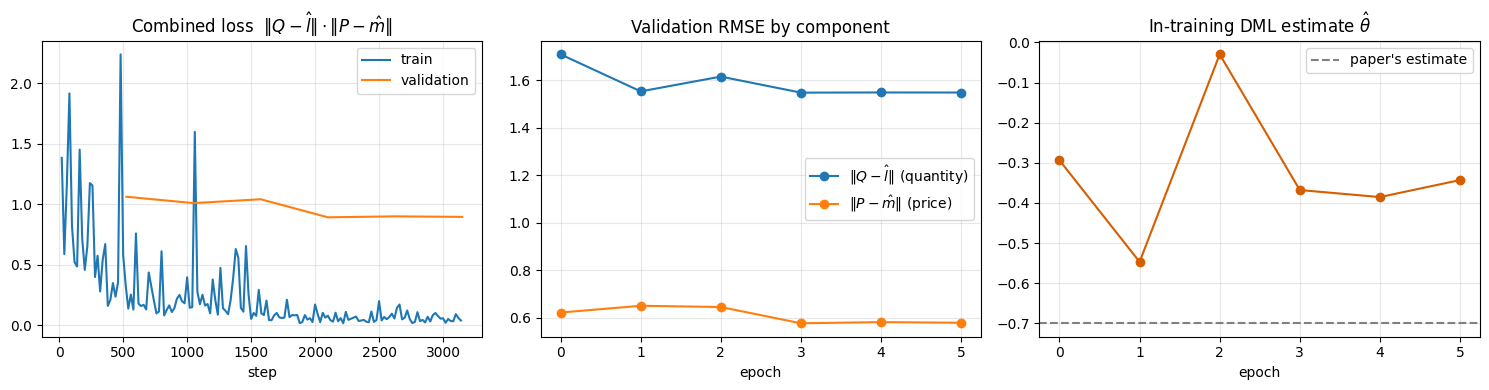

In [10]:
metrics = pd.read_csv(f"{logger.log_dir}/metrics.csv")

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for col, lbl, ax in [("train_combined_loss", "train", axes[0]),
                     ("val_combined_loss", "validation", axes[0])]:
    if col in metrics:
        s = metrics[["step", col]].dropna()
        ax.plot(s["step"], s[col], label=lbl)
axes[0].set_title("Combined loss  $\\|Q-\\hat{l}\\|\\cdot\\|P-\\hat{m}\\|$")
axes[0].set_xlabel("step")
axes[0].legend()

for col, lbl in [("val_RMSE_ml_l_P_bb_t", "$\\|Q-\\hat{l}\\|$ (quantity)"),
                 ("val_RMSE_ml_m_P_bb_t", "$\\|P-\\hat{m}\\|$ (price)")]:
    if col in metrics:
        s = metrics[["epoch", col]].dropna()
        axes[1].plot(s["epoch"], s[col], marker="o", label=lbl)
axes[1].set_title("Validation RMSE by component")
axes[1].set_xlabel("epoch")
axes[1].legend()

if "theta_P_bb_t" in metrics:
    s = metrics[["epoch", "theta_P_bb_t"]].dropna()
    axes[2].plot(s["epoch"], s["theta_P_bb_t"], marker="o", color=palette[3])
    axes[2].axhline(-0.70, ls="--", color="gray", label="paper's estimate")
    axes[2].set_title("In-training DML estimate $\\hat{\\theta}$")
    axes[2].set_xlabel("epoch")
    axes[2].legend()

for ax in axes:
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Extracting the embeddings

The encoders see only time-invariant inputs, so one forward pass per product is enough:
800 rows instead of 11,200. We build a one-row-per-product dataset, run it through the
same preprocessing the data module uses, and read off the embedding.

Setting `shuffle=False, drop_last=False` on the loader keeps the output rows aligned with
the product list.

In [ ]:
gc.collect()
if torch.cuda.is_available():
    torch.cuda.empty_cache()

uniq = df.drop_duplicates("ASIN").sort_values("ASIN").reset_index(drop=True)

ds_uniq = to_hf(uniq).map(
    DoubleMLDeepData.preprocessing_transformation,
    batched=True,
    batch_size=64,
    writer_batch_size=64,
    fn_kwargs={
        "txt_tokenizer": data_module.txt_tokenizer,
        "img_processor": data_module.img_processor,
        "data_field_map": data_field_map,
    },
).remove_columns(["text", "image"])
ds_uniq.set_format(type="torch")

loader = DataLoader(ds_uniq, batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
(outputs, targets) = lit_model.predict_numpy(trainer, loader)
pred_Q, pred_P, E = outputs

assert E.shape[0] == len(uniq), "embedding rows are not aligned with products"
print(f"embeddings: {E.shape}   (one row per product, {EMB_DIM} dimensions)")

/usr/local/lib/python3.13/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


Map:   0%|          | 0/800 [00:00<?, ? examples/s]

## From 1888 dimensions to five interpretable features

This is Algorithm 1 of the paper's Online Appendix.

1. **Random projection.** Multiply by a Gaussian matrix to get
   $\bar{E}_i \in \mathbb{R}^{256}$. By Johnson-Lindenstrauss this approximately preserves
   pairwise distances, so it drops dimensions without distorting the geometry. Unlike a
   learned compression it needs no fitting and cannot overfit.
2. **Centre and normalise** onto the unit hypersphere:
   $$X^e_i = \frac{\bar{E}_i - \frac{1}{n}\sum_j \bar{E}_j}
                  {\|\bar{E}_i - \frac{1}{n}\sum_j \bar{E}_j\|}.$$
   Products are then compared by direction rather than magnitude.
3. **Summaries.** Five principal components $X^{pc}_{i,k} = \gamma_k^\top X^e_i$ and five
   cosine similarities to the $k$-means centroids $X^{sim}_{i,k} = c_k^\top X^e_i$.

The paper works with the similarities rather than the principal components, since
closeness to the die-cast replica cluster is easier to interpret than a loading on the
second principal axis. Lab 5 uses them as the variables the elasticity depends on.

In [ ]:
proj = GaussianRandomProjection(n_components=PROJECTION_DIM, random_state=SEED)
E_bar = proj.fit_transform(E)
X_e = normalize(E_bar - E_bar.mean(axis=0), axis=1)

pca = PCA(n_components=N_COMPONENTS, random_state=SEED)
X_pc = pca.fit_transform(X_e)

km = KMeans(n_clusters=N_CLUSTERS, random_state=SEED, n_init=200).fit(X_e)
X_sim = normalize(X_e) @ normalize(km.cluster_centers_).T

emb_cols = [f"emb_{i}" for i in range(PROJECTION_DIM)]
pca_cols = [f"pca_{i}" for i in range(N_COMPONENTS)]
sim_cols = [f"similarity_cluster_{i}" for i in range(N_CLUSTERS)]

product_features = pd.concat([
    uniq[["ASIN"]],
    pd.DataFrame(X_e, columns=emb_cols),
    pd.DataFrame(X_pc, columns=pca_cols),
    pd.DataFrame(X_sim, columns=sim_cols),
], axis=1)

print(f"X^e: {X_e.shape}   unit norm: "
      f"{np.allclose(np.linalg.norm(X_e, axis=1), 1.0)}")
print(f"variance explained by the first {N_COMPONENTS} PCs: "
      f"{pca.explained_variance_ratio_.sum():.1%}")
print("\nproducts per cluster:")
print(pd.Series(km.labels_).value_counts().sort_index().to_string())

## Checking the embeddings

Before using these vectors as controls it is worth looking at them. We run the paper's two
checks: project onto the first three principal components and colour by cluster, then read
the products closest to each centroid.

In [ ]:
coords = PCA(n_components=3, random_state=SEED).fit_transform(X_e)

fig = plt.figure(figsize=(9, 7))
ax = fig.add_subplot(111, projection="3d")
for k in range(N_CLUSTERS):
    m = km.labels_ == k
    ax.scatter(coords[m, 0], coords[m, 1], coords[m, 2],
               s=12, alpha=0.6, color=palette[k], label=f"Cluster {k}")
ax.set_xlabel("PC 1")
ax.set_ylabel("PC 2")
ax.set_zlabel("PC 3")
ax.set_title("Fine-tuned product embeddings, coloured by $k$-means cluster")
ax.legend(markerscale=2, fontsize=9)
plt.tight_layout()
plt.show()

In [ ]:
n_show = 5
dists = km.transform(X_e)

fig, axes = plt.subplots(N_CLUSTERS, n_show, figsize=(2.1 * n_show, 2.3 * N_CLUSTERS))
for k in range(N_CLUSTERS):
    closest = np.argsort(dists[:, k])[:n_show]
    for j, idx in enumerate(closest):
        asin = uniq["ASIN"].iloc[idx]
        ax = axes[k, j]
        ax.imshow(Image.open(io.BytesIO(images[asin]["bytes"])))
        ax.axis("off")
        if j == 0:
            ax.set_title(f"Cluster {k}", loc="left", fontsize=11, weight="bold")
plt.suptitle("Products closest to each cluster centroid", y=1.005)
plt.tight_layout()
plt.show()

for k in range(N_CLUSTERS):
    closest = np.argsort(dists[:, k])[:3]
    print(f"\n--- Cluster {k} ---")
    for idx in closest:
        row = uniq.iloc[idx]
        print(f"  [{row['subcat_aggregated']}] {row['text'][:110]}")

## Saving the artifact

Labs 3, 4 and 5 run in their own Colab sessions and `/content` does not survive that, so
Google Drive is what carries the embeddings across. The file is a few megabytes.

If you would rather not mount Drive, the notebook also writes a local copy that you can
download and upload again in the next lab.

In [ ]:
TABULAR_RENAME = {
    "New Offer Count: Current": "n_offers",
    "Count of retrieved live offers: New, FBA": "n_offers_fba",
    "Count of retrieved live offers: New, FBM": "n_offers_fbm",
    "Lightning Deals: Upcoming Deal": "lightning_deal",
    "Buy Box: Is FBA": "is_fba",
}

keep = (["ASIN", "date", "period", "split", "subcat_aggregated",
         "Q_t", "P_bb_t", "Q_t-1", "P_bb_t-1", "Delta_Q_t", "Delta_P_bb_t",
         "RATING", "REVIEW_COUNT", "RATING_t-1", "REVIEW_COUNT_t-1"]
        + list(TABULAR_RENAME) + SUBCAT_COLS)

artifact = (df[keep]
            .rename(columns=TABULAR_RENAME)
            .merge(product_features, on="ASIN", how="left"))

assert artifact[emb_cols].notna().all().all(), "some products lack an embedding"
print(f"artifact: {artifact.shape[0]:,} rows x {artifact.shape[1]:,} columns")
artifact.head(3)

In [ ]:
ARTIFACT_NAME = "subsample_v2.parquet"
paths = []

try:
    from google.colab import drive
    drive.mount("/content/drive")
    drive_dir = "/content/drive/MyDrive/demand_labs_v2"
    os.makedirs(drive_dir, exist_ok=True)
    paths.append(os.path.join(drive_dir, ARTIFACT_NAME))
except Exception as exc:
    print(f"Drive not mounted ({type(exc).__name__}); writing a local copy only.")

paths.append(os.path.join("/content" if os.path.isdir("/content") else ".",
                          ARTIFACT_NAME))

for p in paths:
    artifact.to_parquet(p, index=False)
    print(f"wrote {p}  ({os.path.getsize(p) / 1e6:.1f} MB)")

In [ ]:
# Optional: download the artifact to your machine instead of using Drive.
# from google.colab import files
# files.download(paths[-1])

## What we have

One embedding per product, fine-tuned to predict price and quantity, compressed to 256
dimensions and summarised by five principal components and five cluster similarities, all
fitted on products that Labs 4 and 5 will not estimate on.

The clusters are recognisable: die-cast replicas, large utility trucks, playsets and so
on. That says the representation is not noise, but it does not show the embeddings are
useful. For that we need to know what they predict.

* **Lab 3** measures this for $Q$, $P$, $\Delta Q$ and $\Delta P$. The gap between levels
  and changes is what the following labs turn on.
* **Lab 4** uses the embeddings as controls to estimate the average price elasticity.
* **Lab 5** uses the cluster similarities as effect modifiers, letting the elasticity vary
  across the product space.